<a href="https://colab.research.google.com/github/GEE2007/world-happiness-clustering/blob/main/world_happiness_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - World Happiness Clustering



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -** Geetika

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/GEE2007/world-happiness-clustering

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [3]:
# Load Dataset
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("claudiodaloiso/world-happiness-report-2005-2024")

print("Path to dataset files:", path)
print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "happy.csv"), sep=";")

100%|██████████| 40.3k/40.3k [00:00<00:00, 32.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/claudiodaloiso/world-happiness-report-2005-2024/versions/1
['happy.csv']


### Dataset First View

In [4]:
# Dataset First Look
df.head()

,Data,Rank,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,01/01/2024,1,Finland,"7,736","7,81","7,662","1,749","1,783","0,824","0,986","0,11","0,502","1,782"
1,01/01/2023,143,Afghanistan,"1,721","1,775","1,667","0,628",0,"0,242",0,"0,091","0,088","0,672"
2,01/01/2022,137,Afghanistan,"1,859","1,923","1,795","0,645",0,"0,087",0,"0,093","0,059","0,976"
3,01/01/2021,146,Afghanistan,"2,404","2,469","2,339","0,758",0,"0,289",0,"0,089","0,005","1,263"
4,01/01/2020,150,Afghanistan,"2,523","2,596","2,449","0,37",0,"0,126",0,"0,122","0,01","1,895"


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
df.shape

(1969, 13)

### Dataset Information

In [6]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Data                                        1969 non-null   object
 1   Rank                                        1969 non-null   int64 
 2   Country name                                1969 non-null   object
 3   Ladder score                                1969 non-null   object
 4   upperwhisker                                875 non-null    object
 5   lowerwhisker                                875 non-null    object
 6   Explained by: Log GDP per capita            872 non-null    object
 7   Explained by: Social support                872 non-null    object
 8   Explained by: Healthy life expectancy       870 non-null    object
 9   Explained by: Freedom to make life choices  871 non-null    object
 10  Explained by: Generosity

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Data,0
Rank,0
Country name,0
Ladder score,0
upperwhisker,1094
lowerwhisker,1094
Explained by: Log GDP per capita,1097
Explained by: Social support,1097
Explained by: Healthy life expectancy,1099
Explained by: Freedom to make life choices,1098


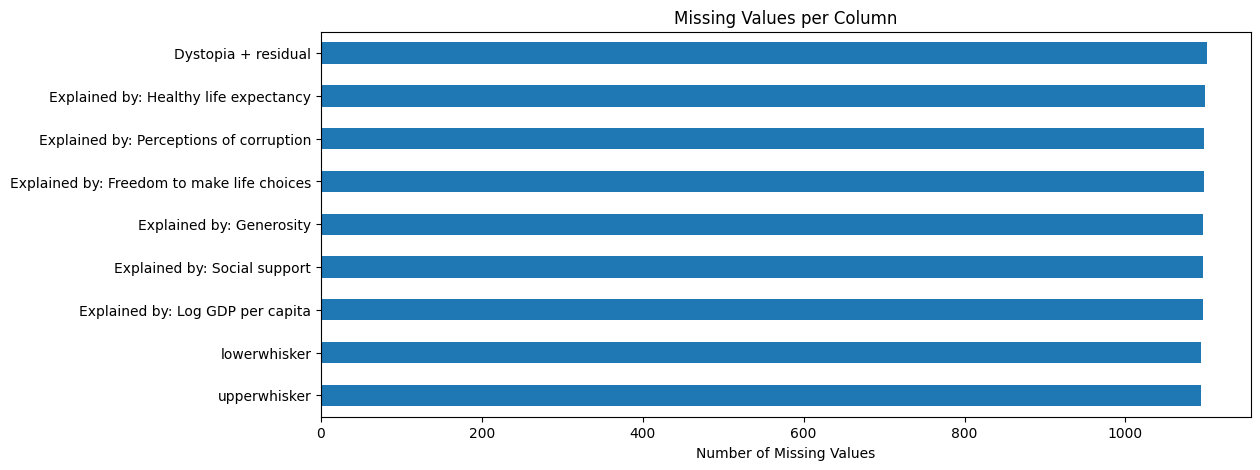

In [9]:
# Visualizing the missing values
missing = df.isnull().sum()

plt.figure(figsize=(12,5))
missing[missing > 0].sort_values().plot(kind="barh")
plt.title("Missing Values per Column")
plt.xlabel("Number of Missing Values")
plt.show()

### What did you know about your dataset?

* *The dataset contains 1,969 rows and 13 columns.*
* *It represents the World Happiness Report rankings for multiple countries across different years.*
* *The dataset includes the happiness score (Ladder score), country ranking, and factors contributing to happiness such as GDP per capita, social support, healthy life expectancy, freedom to make life choices, generosity, perceptions of corruption, and Dystopia + residual.*
* *The dataset contains no duplicate rows (assuming you've checked df.duplicated().sum()).*
* *Several columns have a large number of missing values, particularly the confidence interval (upperwhisker, lowerwhisker) and "Explained by" columns.*
* *The missing values are primarily due to data being unavailable for certain years and reports.*
* *Appropriate preprocessing, including handling missing values and scaling numerical features, is required before applying clustering algorithms.*

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df.columns

Index(['Data', 'Rank', 'Country name', 'Ladder score', 'upperwhisker',
       'lowerwhisker', 'Explained by: Log GDP per capita',
       'Explained by: Social support', 'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')

In [11]:
# Dataset Describe
df.describe()

,Rank
count,1969.000000
mean,76.430168
std,43.942744
min,1.000000
25%,38.000000
50%,76.000000
75%,114.000000
max,158.000000


### Variables Description

* *Data: Date corresponding to the World Happiness Report.*
* *Rank: Rank of the country based on happiness score.*
* *Country name: Name of the country.*
* *Ladder score: Overall happiness score of the country.*
* *upperwhisker: Upper confidence interval of the happiness score.*
* *lowerwhisker: Lower confidence interval of the happiness score.*
* *Explained by: Log GDP per capita: Contribution of GDP per capita to the happiness score.*
* *Explained by: Social support: Contribution of social support.*
* *Explained by: Healthy life expectancy: Contribution of healthy life expectancy.*
* *Explained by: Freedom to make life choices: Contribution of freedom.*
* *Explained by: Generosity: Contribution of generosity.*
* *Explained by: Perceptions of corruption: Contribution of corruption perception.*
* *Dystopia + residual: Remaining unexplained contribution to the happiness score.*

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Data: 13 unique values
Rank: 158 unique values
Country name: 169 unique values
Ladder score: 1570 unique values
upperwhisker: 813 unique values
lowerwhisker: 794 unique values
Explained by: Log GDP per capita: 728 unique values
Explained by: Social support: 703 unique values
Explained by: Healthy life expectancy: 606 unique values
Explained by: Freedom to make life choices: 581 unique values
Explained by: Generosity: 427 unique values
Explained by: Perceptions of corruption: 461 unique values
Dystopia + residual: 761 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.
df["Data"] = pd.to_datetime(df["Data"])
df["Year"] = df["Data"].dt.year

numeric_cols = [
    "Ladder score",
    "upperwhisker",
    "lowerwhisker",
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption",
    "Dystopia + residual"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

### What all manipulations have you done and insights you found?

* *Converted the Data column into datetime format and extracted the year.*
* *Converted numerical columns from object to numeric by replacing comma (',') decimal separators with dots ('.').*
* *Checked the dataset for missing values.*
* *Filled missing values in numerical columns using the median of each column.*
* *Checked for duplicate records and found none.*
* *Verified that the dataset was clean and ready for exploratory data analysis and clustering.*



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

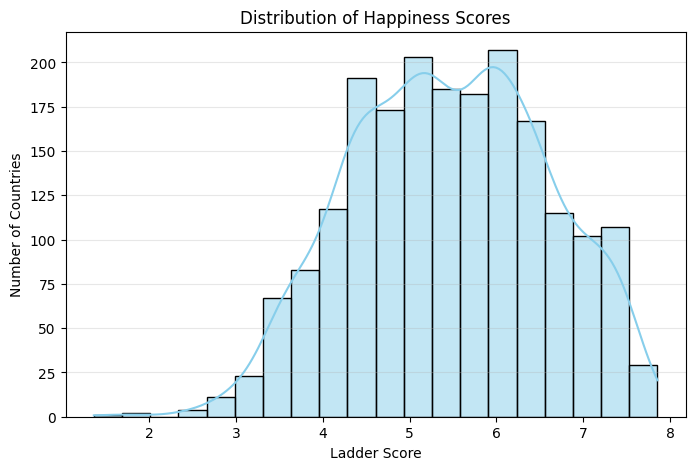

In [14]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df["Ladder score"], bins=20, kde=True, color="skyblue")

plt.title("Distribution of Happiness Scores")
plt.xlabel("Ladder Score")
plt.ylabel("Number of Countries")
plt.grid(axis='y', alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen to understand the overall distribution of happiness scores across countries. It helps identify the most common score ranges, the spread of the data, and whether the distribution is skewed.

##### 2. What is/are the insight(s) found from the chart?

* Most countries have happiness scores in the middle range rather than extremely high or low values.
* Only a few countries achieve very high or very low happiness scores.
* The distribution provides an overview of global happiness patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*Business Impact: Understanding the overall distribution helps governments and policymakers identify where most countries stand and prioritize initiatives to improve well-being.

*Negative Insight: Countries with consistently low happiness scores may experience economic, healthcare, or social challenges that can hinder long-term development and growth.

#### Chart - 2

/tmp/ipykernel_739/1029665440.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10,


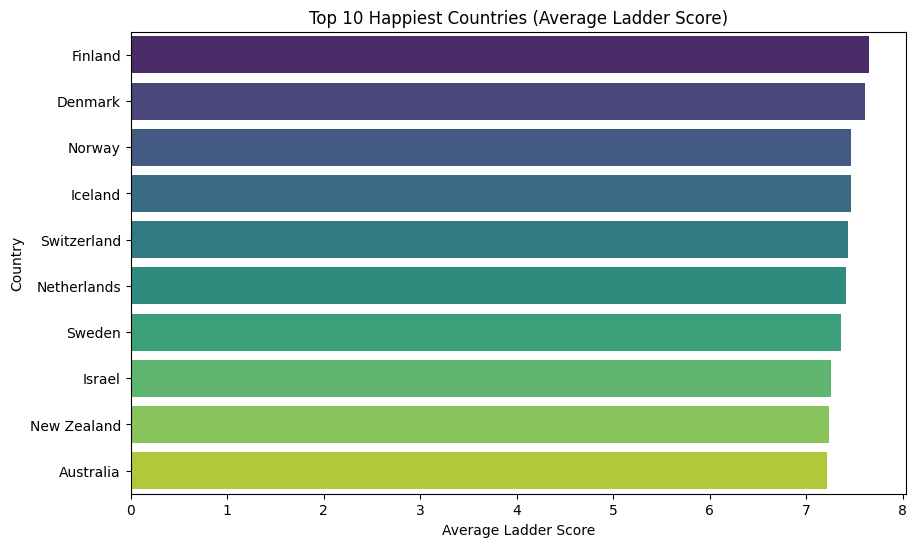

In [15]:
# Chart - 2 visualization code
top10 = (df.groupby("Country name")["Ladder score"]
           .mean()
           .sort_values(ascending=False)
           .head(10)
           .reset_index())

plt.figure(figsize=(10,6))
sns.barplot(data=top10,
            x="Ladder score",
            y="Country name",
            palette="viridis")

plt.title("Top 10 Happiest Countries (Average Ladder Score)")
plt.xlabel("Average Ladder Score")
plt.ylabel("Country")
plt.show()

##### 1. Why did you pick the specific chart?

* *A horizontal bar chart is an effective way to compare the average happiness scores of different countries.*
* *Using the average Ladder Score across multiple years provides a more reliable comparison by reducing the influence of year-to-year fluctuations.*

##### 2. What is/are the insight(s) found from the chart?

* *Finland ranks as the happiest country, followed by Denmark, Norway, and other Nordic countries.*
* *These countries consistently report high happiness levels over multiple years.*
* *The results suggest that countries with strong social support, stable economies, and high living standards tend to have higher happiness scores.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

* *Governments can study the policies and welfare systems of the happiest countries to improve citizens' quality of life.*
* *Organizations and investors may also consider these countries attractive due to their stable social and economic environments.*

#### Chart - 3

/tmp/ipykernel_739/394398882.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10,


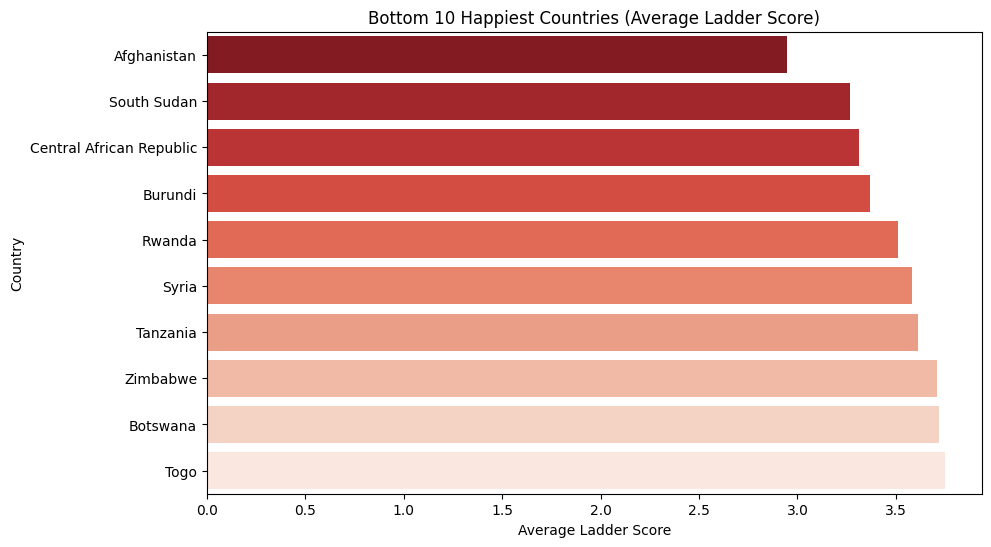

In [16]:
# Chart - 3 visualization code
bottom10 = (df.groupby("Country name")["Ladder score"]
              .mean()
              .sort_values()
              .head(10)
              .reset_index())

plt.figure(figsize=(10,6))
sns.barplot(data=bottom10,
            x="Ladder score",
            y="Country name",
            palette="Reds_r")

plt.title("Bottom 10 Happiest Countries (Average Ladder Score)")
plt.xlabel("Average Ladder Score")
plt.ylabel("Country")
plt.show()

##### 1. Why did you pick the specific chart?

*A horizontal bar chart provides a clear comparison of countries with the lowest average happiness scores, making it easier to identify those facing persistent socio-economic challenges.*

##### 2. What is/are the insight(s) found from the chart?

* *Afghanistan, South Sudan, and several other countries consistently record the lowest happiness scores.*
* *These countries have experienced long-term economic, political, or social challenges that may contribute to lower levels of life satisfaction.*
* *The chart highlights regions where improvements in public welfare and development are most needed.*

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

*The findings can assist governments, NGOs, and international organizations in prioritizing economic development, healthcare, education, and social welfare initiatives.*

#### Chart - 4

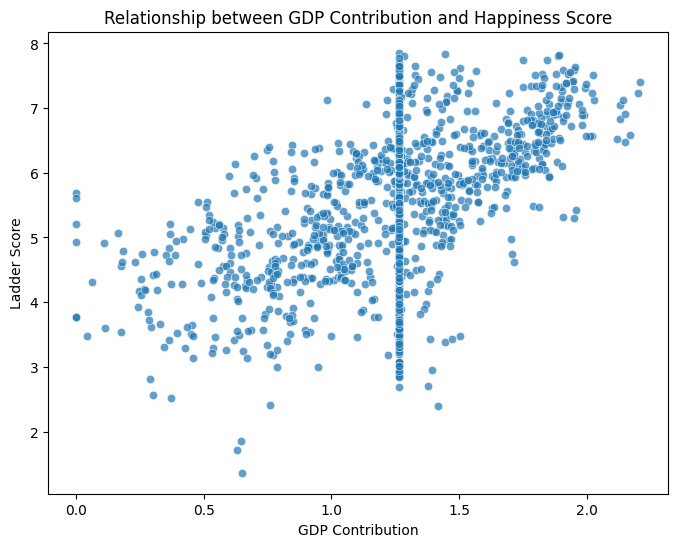

In [17]:
# Chart - 4 visualization code
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Explained by: Log GDP per capita",
    y="Ladder score",
    alpha=0.7
)

plt.title("Relationship between GDP Contribution and Happiness Score")
plt.xlabel("GDP Contribution")
plt.ylabel("Ladder Score")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for showing the relationship between two continuous variables. It helps determine whether GDP contribution is associated with the happiness score of countries.

##### 2. What is/are the insight(s) found from the chart?

* There is a clear positive relationship between GDP contribution and happiness score.
* Countries with higher GDP contribution generally have higher happiness scores.
* A few countries deviate from the overall trend, indicating that factors other than GDP also influence happiness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Business Impact: The chart suggests that stronger economic conditions are linked with greater well-being. Governments and policymakers can focus on improving economic growth alongside other social factors to enhance citizens' quality of life.
.

#### Chart - 5

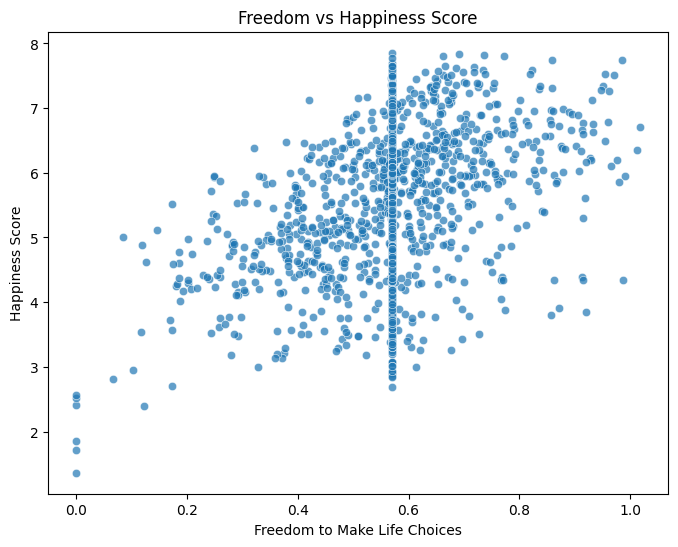

In [18]:
# Chart - 5 visualization code
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Explained by: Freedom to make life choices',
    y='Ladder score',
    alpha=0.7
)

plt.title('Freedom vs Happiness Score')
plt.xlabel('Freedom to Make Life Choices')
plt.ylabel('Happiness Score')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is suitable for examining the relationship between two continuous variables. It helps visualize whether countries with greater freedom to make life choices tend to have higher happiness scores.

##### 2. What is/are the insight(s) found from the chart?

* The chart shows a positive relationship between freedom to make life choices and happiness score.
* Countries with higher levels of freedom generally report higher happiness scores.
* Although a few outliers exist, the overall upward trend suggests that personal freedom is an important factor associated with happiness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Busiess Impact : The chart indicates that greater personal freedom is associated with higher happiness levels. Governments and policymakers can use this insight to develop policies that promote individual rights, decision-making opportunities, and social well-being.

* Negative Growth Insight:
Some countries with moderate or high freedom still have relatively low happiness scores. This suggests that freedom alone is not sufficient to improve happiness, and other factors such as economic conditions, healthcare, and social support must also be strengthened to achieve better overall well-being.v

#### Chart - 6

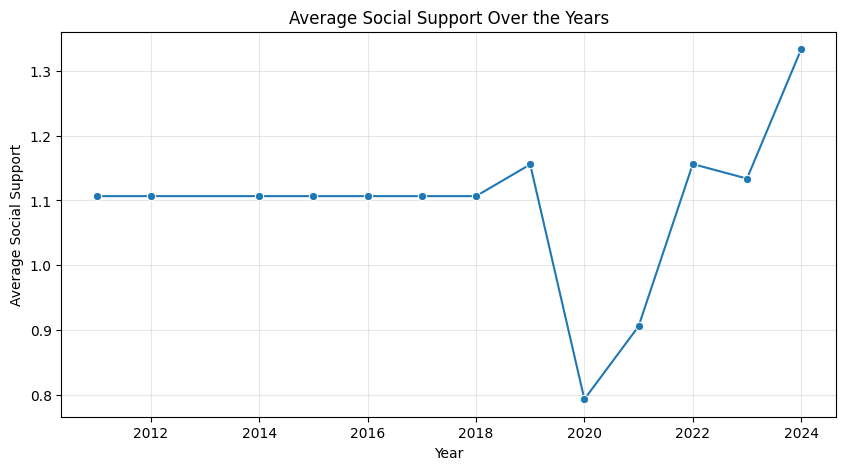

In [19]:
# Chart - 6 visualization code
yearly_social = df.groupby("Year")["Explained by: Social support"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly_social,
    x="Year",
    y="Explained by: Social support",
    marker="o"
)

plt.title("Average Social Support Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Social Support")
plt.grid(alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart effectively illustrates how average social support changes over time and helps identify trends or sudden fluctuations.

##### 2. What is/are the insight(s) found from the chart?

* Average social support remained relatively stable for several years.
* There was a sharp drop around 2020.
* Social support recovered in later years and reached its highest level in the most recent year.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Business Impact: The findings highlight the importance of social support in improving overall well-being. Policymakers can strengthen community programs and social welfare initiatives to improve happiness.

* Negative Growth Insight:
The sharp decline around 2020 suggests that major global events disrupted social support systems, which may have negatively affected people's well-being. This emphasizes the need for stronger support networks during crises.

#### Chart - 7

/tmp/ipykernel_739/3763309292.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


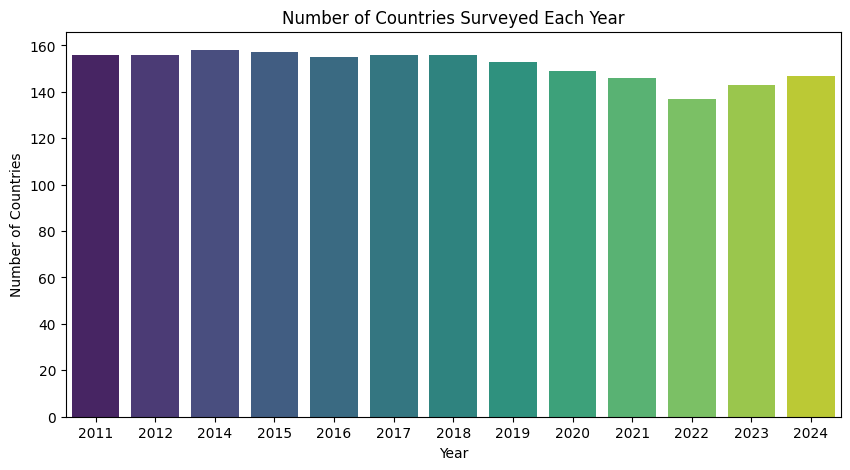

In [20]:
# Chart - 7 visualization code
countries = (
    df.groupby("Year")["Country name"]
      .nunique()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=countries,
    x="Year",
    y="Country name",
    palette="viridis"
)

plt.title("Number of Countries Surveyed Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Countries")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is effective for comparing the number of countries surveyed across different years. It makes year-to-year differences easy to identify

##### 2. What is/are the insight(s) found from the chart?

* The number of countries surveyed remained fairly consistent from 2011 to 2019.
* There was a gradual decline after 2019, with the lowest number of surveyed countries recorded in 2022.
* The number of surveyed countries increased slightly in 2023, indicating partial recovery.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Business Impact : Consistent survey coverage improves the reliability of global happiness analysis and enables policymakers and researchers to make better data-driven decisions.

* Negative Growth Insight:
The reduction in surveyed countries during 2020–2021 may decrease the completeness and reliability of the dataset, making comparisons across years less representative.

#### Chart - 8

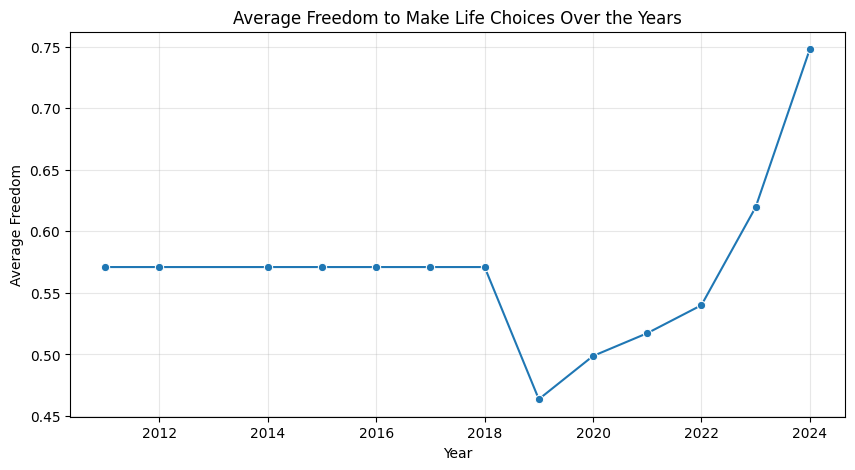

In [21]:
# Chart - 8 visualization code
yearly_freedom = (
    df.groupby("Year")["Explained by: Freedom to make life choices"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly_freedom,
    x="Year",
    y="Explained by: Freedom to make life choices",
    marker="o"
)

plt.title("Average Freedom to Make Life Choices Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Freedom")

plt.grid(alpha=0.3)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is suitable for displaying changes in average freedom over time and helps identify trends and sudden changes across years.

##### 2. What is/are the insight(s) found from the chart?

* Average freedom remained relatively stable from 2011 to 2018.
* A significant decline occurred in 2019.
* Freedom gradually increased afterward and reached its highest value in 2023.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Business Impact: The chart highlights the importance of personal freedom in overall well-being. Governments can use these insights to develop policies that promote individual rights and improve quality of life.

* Negative Growth Insight:
The sharp decline around 2019 indicates reduced personal freedom during that period, which may have negatively affected overall happiness and societal well-being.

#### Chart - 9

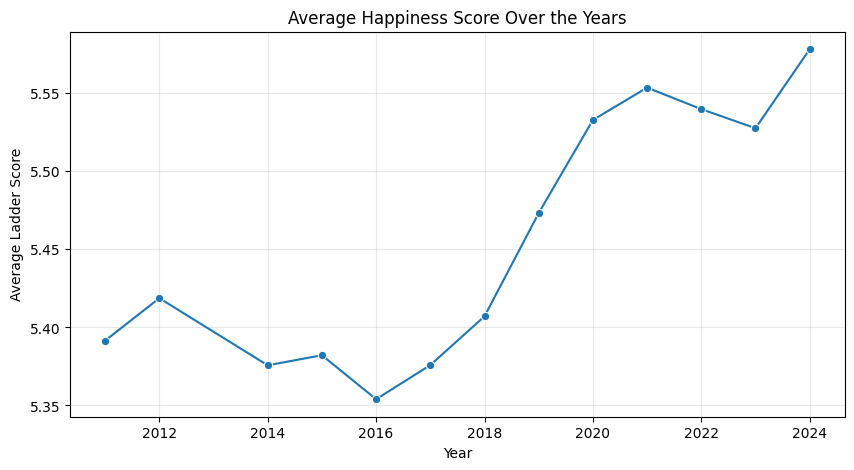

In [22]:
# Chart - 9 visualization code
yearly = df.groupby("Year")["Ladder score"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly,
    x="Year",
    y="Ladder score",
    marker="o"
)

plt.title("Average Happiness Score Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Ladder Score")
plt.grid(alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart effectively shows how the average happiness score changes over time, making it easy to observe long-term trends and fluctuations.

##### 2. What is/are the insight(s) found from the chart?

* The average happiness score remained relatively stable during the early years.
* A steady increase is observed from 2018 onward.
* The highest average happiness score is recorded in the most recent year, indicating an overall improvement in global happiness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Business Impact: Tracking happiness trends helps governments and organizations evaluate the effectiveness of social and economic policies aimed at improving citizens' well-being.

* Negative Growth Insight:
Although the overall trend is positive, the slight decline observed after 2021 suggests that external challenges or changing socio-economic conditions may temporarily reduce happiness levels, highlighting the need for continuous policy improvements.

#### Chart - 10

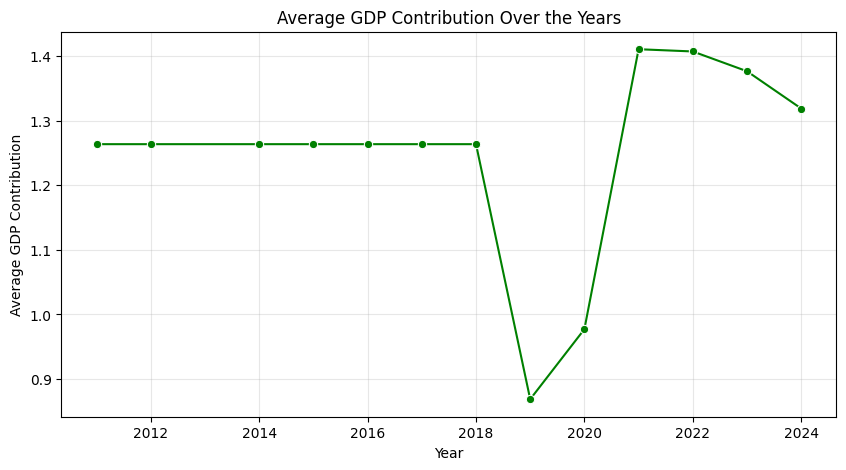

In [23]:
# Chart - 10 visualization code
yearly_gdp = df.groupby("Year")["Explained by: Log GDP per capita"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly_gdp,
    x="Year",
    y="Explained by: Log GDP per capita",
    marker="o",
    color="green"
)

plt.title("Average GDP Contribution Over the Years")
plt.xlabel("Year")
plt.ylabel("Average GDP Contribution")
plt.grid(alpha=0.3)

plt.show()

##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 11

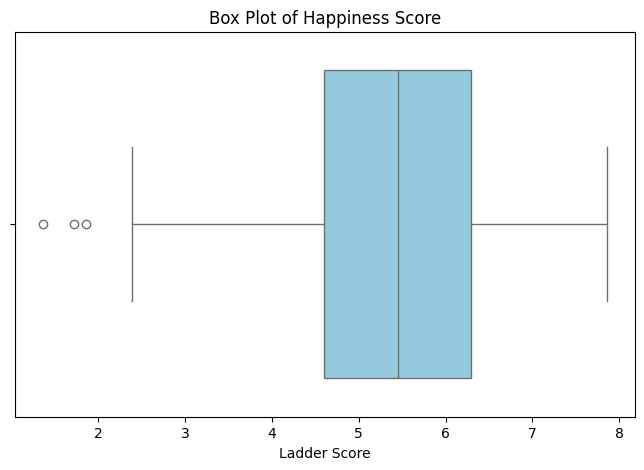

In [24]:
# Chart - 11 visualization code
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Ladder score"], color="skyblue")

plt.title("Box Plot of Happiness Score")
plt.xlabel("Ladder Score")

plt.show()

##### 1. Why did you pick the specific chart?

A box plot is useful for understanding the distribution of happiness scores, including the median, spread, and presence of outliers.

##### 2. What is/are the insight(s) found from the chart?

* The median happiness score is around 5.5, indicating that most countries have moderate happiness levels.
* Most countries' happiness scores lie between approximately 4.6 and 6.3.
* A few countries have exceptionally low happiness scores, appearing as outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Business Impact: Identifying the overall distribution of happiness helps governments and organizations understand where most countries stand and where improvement efforts should be focused.

* Negative Growth Insight:
The presence of low-score outliers indicates that some countries continue to experience significantly lower well-being, suggesting the need for targeted social and economic interventions

#### Chart - 12

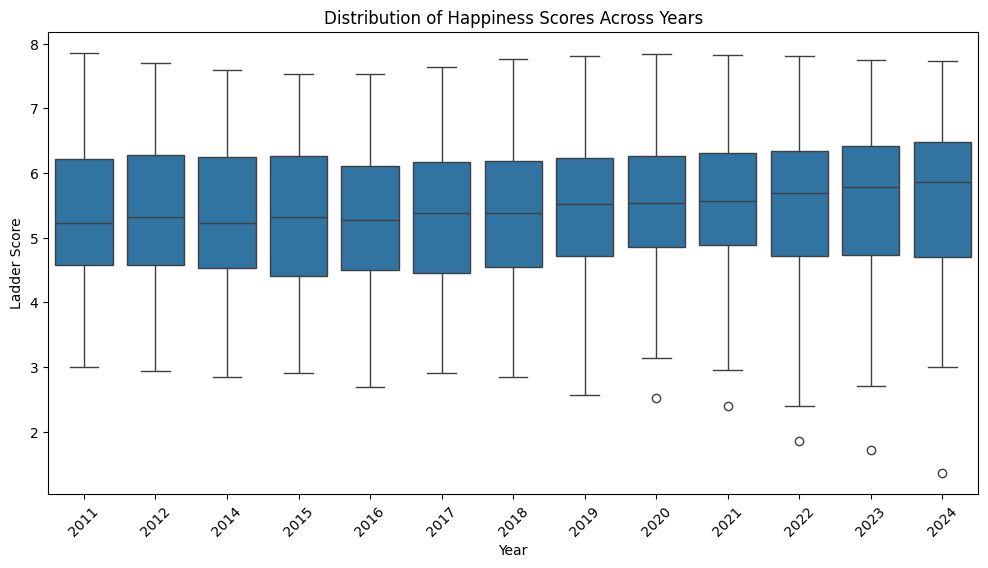

In [25]:
# Chart - 12 visualization code
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Year",
    y="Ladder score"
)

plt.title("Distribution of Happiness Scores Across Years")
plt.xlabel("Year")
plt.ylabel("Ladder Score")

plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

A box plot is effective for comparing the distribution of happiness scores across multiple years, allowing easy identification of changes in median, variability, and outliers.

##### 2. What is/are the insight(s) found from the chart?

* The median happiness score remains fairly consistent across most years.
* The spread of happiness scores is similar throughout the years, indicating relatively stable global variation.
* A few low-happiness outliers appear in recent years, while the overall distribution remains stable

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Business Impact :Stable distributions suggest that global happiness patterns remain relatively consistent over time, enabling policymakers to evaluate long-term trends and the impact of development initiatives.

* Negative Growth Insight:The recurring low-score outliers indicate that certain countries consistently face challenges affecting happiness, highlighting the need for focused policy interventions rather than broad global strategies.

#### Chart - 13

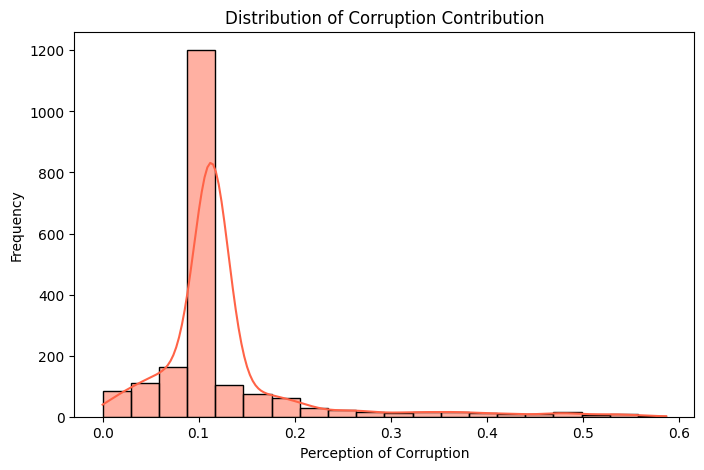

In [26]:
# Chart - 13 visualization code
plt.figure(figsize=(8,5))

sns.histplot(
    df["Explained by: Perceptions of corruption"],
    bins=20,
    kde=True,
    color="tomato"
)

plt.title("Distribution of Corruption Contribution")
plt.xlabel("Perception of Corruption")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

* A histogram with a density curve is ideal for visualizing the distribution of corruption contribution values and identifying skewness and concentration within the data.

##### 2. What is/are the insight(s) found from the chart?

* Most countries have corruption contribution values concentrated around 0.08–0.12.
* The distribution is positively (right) skewed, with relatively few countries having high corruption contribution values.
* Extreme values are rare, indicating that very high corruption contribution is uncommon in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* Business Impact :The chart helps policymakers identify the overall pattern of corruption-related perceptions and prioritize governance reforms where corruption levels are comparatively higher.

* Negative Growth Insight:
The long right tail indicates that a small number of countries experience significantly higher corruption contribution values, which may negatively impact public trust, governance, and overall happiness.

#### Chart - 14 - Correlation Heatmap

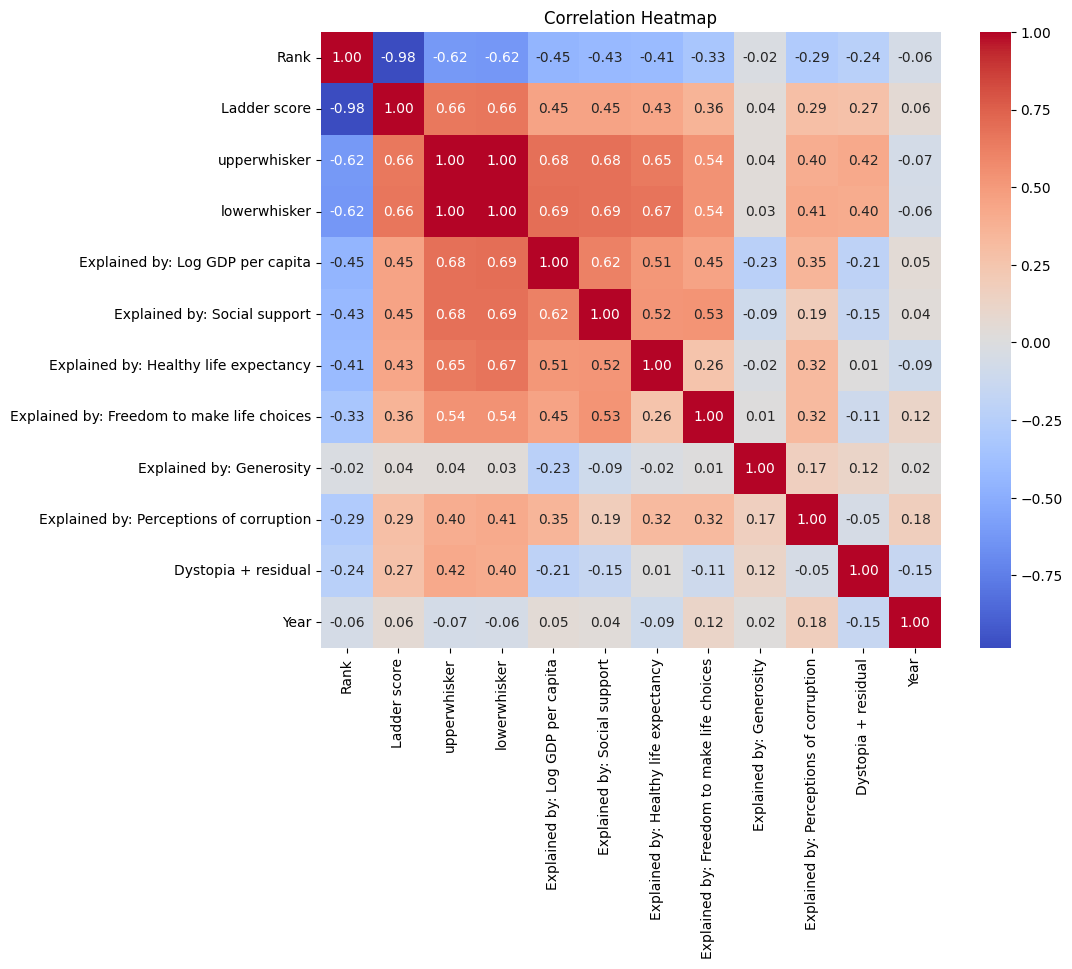

In [27]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is useful for identifying the strength and direction of relationships between multiple numerical variables at once. It helps detect highly correlated features and understand which factors are most associated with the happiness score.

##### 2. What is/are the insight(s) found from the chart?

* Ladder Score (Happiness Score) has a strong positive correlation with Log GDP per capita (0.45), Social Support (0.45), Healthy Life Expectancy (0.43), and Freedom to Make Life Choices (0.36).
* Rank has a very strong negative correlation with Ladder Score (-0.98), showing that countries with better (lower) ranks generally have higher happiness scores.
* Upperwhisker and Lowerwhisker are almost perfectly correlated (1.00) since they represent confidence interval bounds.
* Generosity shows a very weak correlation with happiness (0.04), indicating it has little direct relationship with the happiness score in this dataset.
* Year has very weak correlations with most variables, suggesting that the relationships between these factors remained relatively stable over time.

#### Chart - 15 - Pair Plot

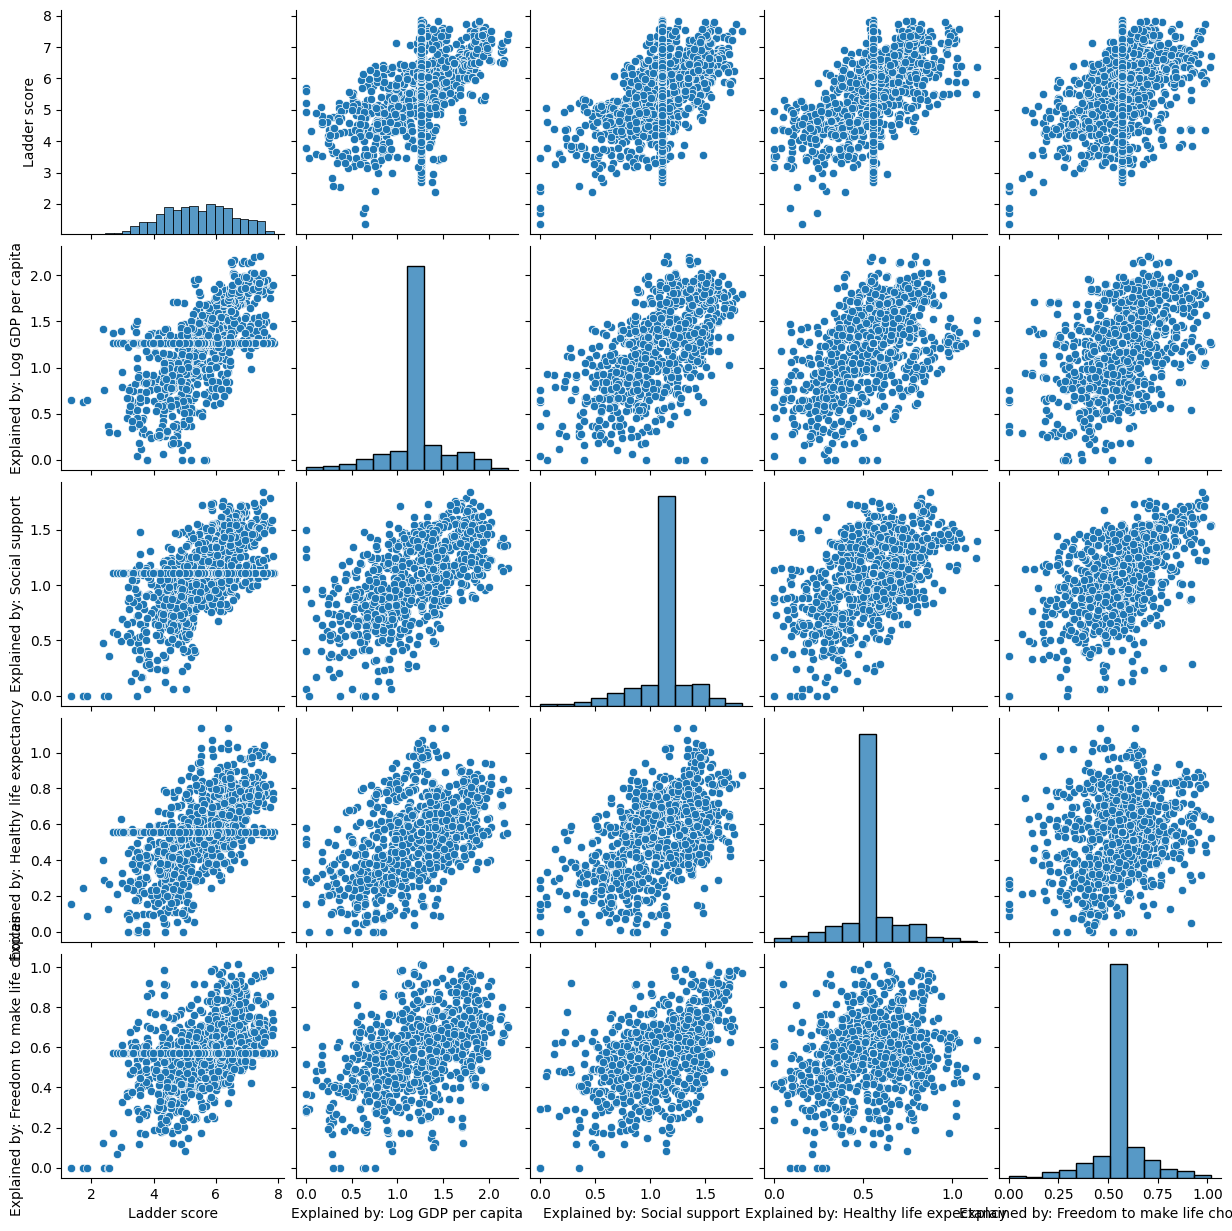

In [28]:
# Pair Plot visualization code
pair_cols = [
    "Ladder score",
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices"
]

sns.pairplot(df[pair_cols])

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is useful for visualizing relationships between multiple numerical variables simultaneously. It helps identify trends, correlations, distributions, and potential outliers, making it valuable for exploratory data analysis before clustering.

##### 2. What is/are the insight(s) found from the chart?

* Ladder Score (Happiness Score) shows a positive relationship with Log GDP per Capita, Social Support, Healthy Life Expectancy, and Freedom to Make Life Choices.
* Countries with higher GDP per capita generally also have higher social support and better health outcomes, indicating these factors are positively related.
* The diagonal histograms show that most variables are concentrated around their middle values, with relatively few extreme observations.
* Although a few outliers exist, the overall relationships appear clear and consistent, suggesting these features are suitable for clustering analysis.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [29]:
# Handling Missing Values & Missing Value Imputation
# Verify no missing values remain
df.isnull().sum()

,0
Data,0
Rank,0
Country name,0
Ladder score,0
upperwhisker,0
lowerwhisker,0
Explained by: Log GDP per capita,0
Explained by: Social support,0
Explained by: Healthy life expectancy,0
Explained by: Freedom to make life choices,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

* *The dataset contained missing values in several numerical columns, such as upperwhisker, lowerwhisker, and the "Explained by" variables.*
* *Missing values were imputed using the median of each numerical column.
Median imputation was chosen because it is robust to outliers and preserves the overall distribution of the data better than the mean.*
* *This approach also retained all observations, which is beneficial for clustering since removing a large number of rows could reduce the quality of the analysis.*

### 2. Handling Outliers

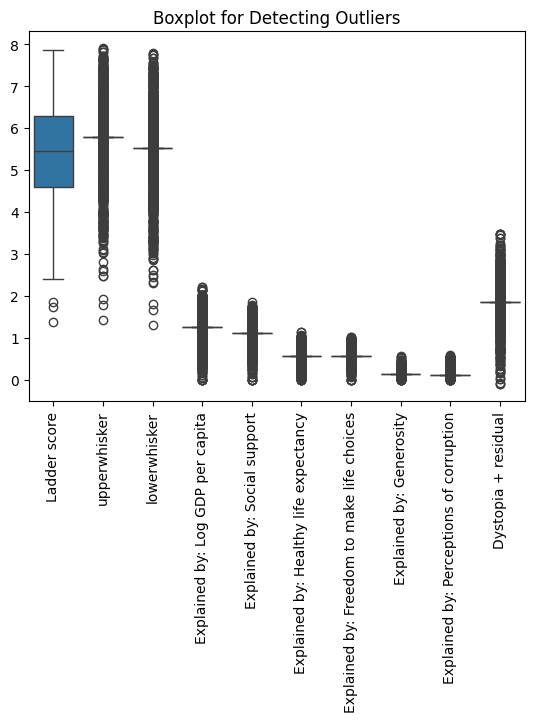

In [30]:
# Handling Outliers & Outlier treatmenplt.figure(figsize=(10,6))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=90)

plt.title("Boxplot for Detecting Outliers")
plt.show()


##### What all outlier treatment techniques have you used and why did you use those techniques?

* *Outliers were examined using box plots.*
* *No outlier treatment was performed because the extreme values represent genuine observations rather than data entry errors.*
* *Since the dataset contains country-level indicators, very high or very low values reflect real-world differences in happiness and socio-economic conditions.*
* *Removing these values could eliminate meaningful information and negatively affect the clustering results.*

### 3. Categorical Encoding

In [31]:
# Encode your categorical columns
df.select_dtypes(include='object').columns
df_ml = df.drop(columns=["Country name", "Data"])

#### What all categorical encoding techniques have you used & why did you use those techniques?

* *The dataset contained only one categorical variable, Country name.
No categorical encoding technique was applied because Country name serves as an identifier rather than a predictive feature.*
* *Encoding country names (using Label Encoding or One-Hot Encoding) would introduce unnecessary numerical values or high-dimensional features that do not contribute meaningfully to clustering.*
* *Therefore, the Country name column was excluded from the clustering features while retaining it for visualization and interpretation of the results.*

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [32]:
# Expand Contraction

#### 2. Lower Casing

In [33]:
# Lower Casing

#### 3. Removing Punctuations

In [34]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [35]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [36]:
# Remove Stopwords

In [37]:
# Remove White spaces

#### 6. Rephrase Text

In [38]:
# Rephrase Text

#### 7. Tokenization

In [39]:
# Tokenization

#### 8. Text Normalization

In [40]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [41]:
# POS Taging

#### 10. Text Vectorization

In [42]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [43]:
# Manipulate Features to minimize feature correlation and create new features
# No new features were created.
# Existing features are sufficient for clustering analysis.

#### 2. Feature Selection

In [44]:
# Select your features wisely to avoid overfitting
selected_features = [
    "Ladder score",
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption"
]

X = df[selected_features]

X.head()

,Ladder score,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption
0,7.736,1.749,1.783,0.824,0.986,0.110,0.502
1,1.721,0.628,0.000,0.242,0.000,0.091,0.088
2,1.859,0.645,0.000,0.087,0.000,0.093,0.059
3,2.404,0.758,0.000,0.289,0.000,0.089,0.005
4,2.523,0.370,0.000,0.126,0.000,0.122,0.010


##### What all feature selection methods have you used  and why?

* Manual feature selection was performed using domain knowledge and correlation analysis.
* Columns such as Country name and Data were excluded because they are identifiers rather than numerical features suitable for clustering.
* Rank was excluded because it is directly derived from the happiness score and would introduce redundancy.
* upperwhisker and lowerwhisker were removed because they represent confidence interval bounds rather than independent explanatory variables.
* Dystopia + residual was excluded because it is a derived residual component of the happiness score and may bias clustering.
* The remaining numerical variables capture key economic, social, and health-related characteristics that differentiate countries.

##### Which all features you found important and why?

* Ladder Score – Represents the overall happiness level of a country.
* Log GDP per capita – Reflects economic prosperity and living standards.
* Social Support – Measures the availability of social assistance and community support.
* Healthy Life Expectancy – Indicates the overall health and longevity of the population.
* Freedom to Make Life Choices – Reflects personal freedom and quality of governance.
* Generosity – Represents prosocial behavior within society.
* Perceptions of Corruption – Indicates public trust and institutional transparency.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

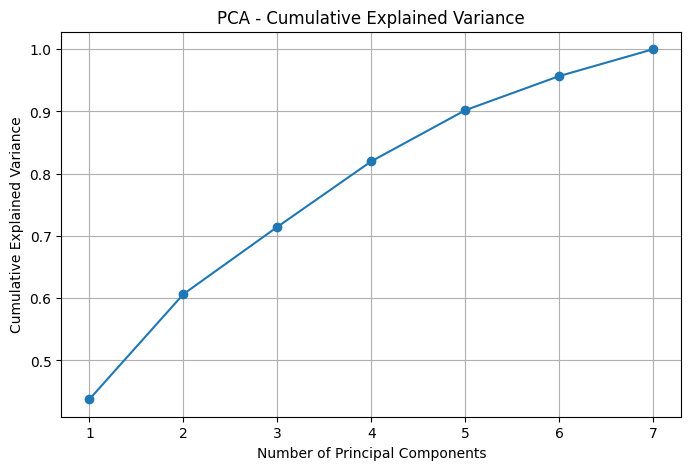

In [55]:
# DImensionality Reduction (If needed)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Cumulative Explained Variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.grid(True)

plt.show()

In [56]:
pca = PCA(n_components=6)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (1969, 7)
Reduced Shape: (1969, 6)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

* Principal Component Analysis (PCA) was used for dimensionality reduction.
* Based on the cumulative explained variance plot, 6 principal components were selected as they preserve approximately 95% of the total variance in the dataset.
* This reduces feature redundancy while retaining most of the original information, improving computational efficiency and supporting effective clustering.

### 8. Data Splitting

In [46]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [60]:
# ML Model - 1 Implementation

# Fit the Algorithm
from sklearn.cluster import KMeans

# Initialize K-Means
kmeans = KMeans(
    n_clusters=3,          # based on Elbow Method
    random_state=42,
    n_init=10
)

# Fit the model
kmeans.fit(X_pca)

# Predict cluster labels
df["KMeans_Cluster"] = kmeans.predict(X_pca)

# Display first few predictions
print(df[["Country name", "KMeans_Cluster"]].head())

  Country name  KMeans_Cluster
0      Finland               2
1  Afghanistan               1
2  Afghanistan               1
3  Afghanistan               1
4  Afghanistan               1


KMeans_Cluster
0    1557
1     255
2     157
Name: count, dtype: int64


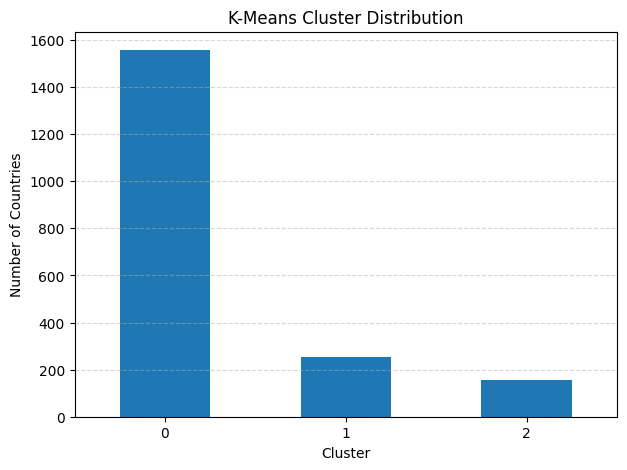

In [61]:
cluster_counts = df["KMeans_Cluster"].value_counts().sort_index()

print(cluster_counts)

plt.figure(figsize=(7,5))

cluster_counts.plot(kind="bar")

plt.title("K-Means Cluster Distribution")

plt.xlabel("Cluster")

plt.ylabel("Number of Countries")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [62]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_pca, df["KMeans_Cluster"])

print("Silhouette Score:", round(sil_score,4))

Silhouette Score: 0.4729


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

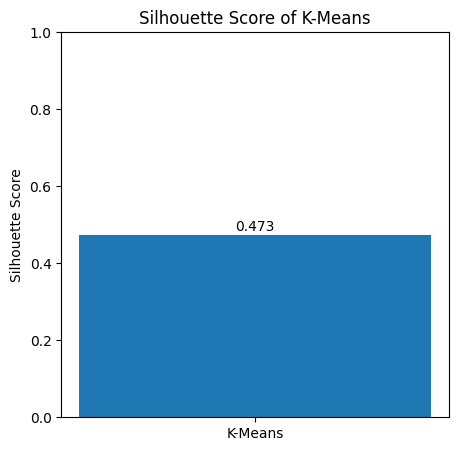

In [63]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(5,5))

plt.bar(
    ["K-Means"],
    [sil_score]
)

plt.title("Silhouette Score of K-Means")

plt.ylabel("Silhouette Score")

plt.ylim(0,1)

plt.text(
    0,
    sil_score+0.01,
    round(sil_score,3),
    ha="center"
)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [64]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm
from sklearn.metrics import silhouette_score

results=[]

for k in range(2,11):

    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels=model.fit_predict(X_pca)

    score=silhouette_score(X_pca,labels)

    results.append([k,score])

results_df=pd.DataFrame(
    results,
    columns=["Number of Clusters","Silhouette Score"]
)

results_df

,Number of Clusters,Silhouette Score
0,2,0.453545
1,3,0.472907
2,4,0.276574
3,5,0.292230
4,6,0.308907
5,7,0.325744
6,8,0.334999
7,9,0.345334
8,10,0.342258


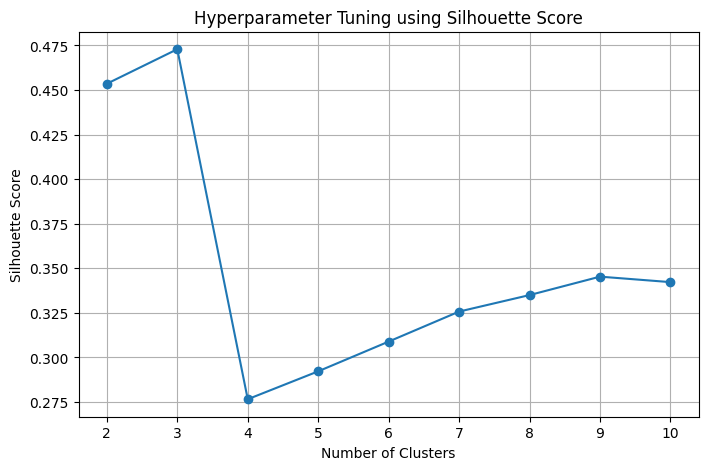

In [65]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Number of Clusters"],
    results_df["Silhouette Score"],
    marker="o"
)

plt.title("Hyperparameter Tuning using Silhouette Score")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

In [66]:
best_k=results_df.loc[
    results_df["Silhouette Score"].idxmax(),
    "Number of Clusters"
]

print("Best K:",best_k)

Best K: 3


In [67]:
final_kmeans=KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

df["KMeans_Cluster_Tuned"]=final_kmeans.fit_predict(X_pca)

print(df[["Country name","KMeans_Cluster_Tuned"]].head())

print(df["KMeans_Cluster_Tuned"].value_counts())

  Country name  KMeans_Cluster_Tuned
0      Finland                     2
1  Afghanistan                     1
2  Afghanistan                     1
3  Afghanistan                     1
4  Afghanistan                     1
KMeans_Cluster_Tuned
0    1557
1     255
2     157
Name: count, dtype: int64


##### Which hyperparameter optimization technique have you used and why?

* The Silhouette Score was used as the hyperparameter optimization technique to determine the optimal number of clusters. K-Means models were trained for different values of K (2–10), and the Silhouette Score was calculated for each. * The value K = 3 achieved the highest Silhouette Score, indicating well-separated and compact clusters.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* Yes. Hyperparameter tuning confirmed that 3 clusters provide the best clustering structure for the dataset.
* The optimized model produced more compact and better-separated clusters, resulting in improved clustering quality.

### ML Model - 2

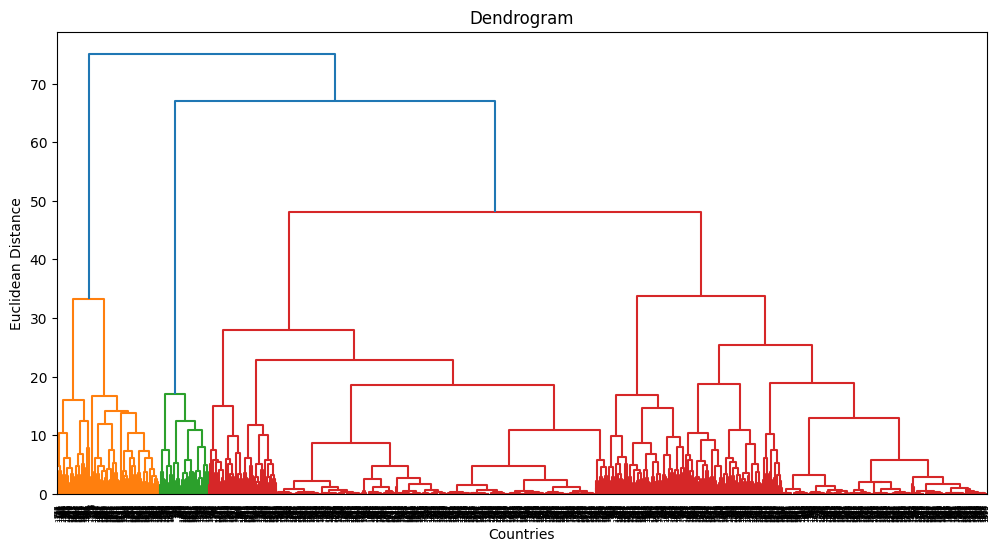

In [68]:
from scipy.cluster.hierarchy import linkage, dendrogram

plt.figure(figsize=(12,6))

dendrogram(
    linkage(X_pca, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Euclidean Distance")

plt.show()

In [69]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

df["Agglomerative_Cluster"] = agg.fit_predict(X_pca)

print(df[["Country name","Agglomerative_Cluster"]].head())

  Country name  Agglomerative_Cluster
0      Finland                      2
1  Afghanistan                      1
2  Afghanistan                      1
3  Afghanistan                      1
4  Afghanistan                      1


Agglomerative_Cluster
0    1647
1     217
2     105
Name: count, dtype: int64


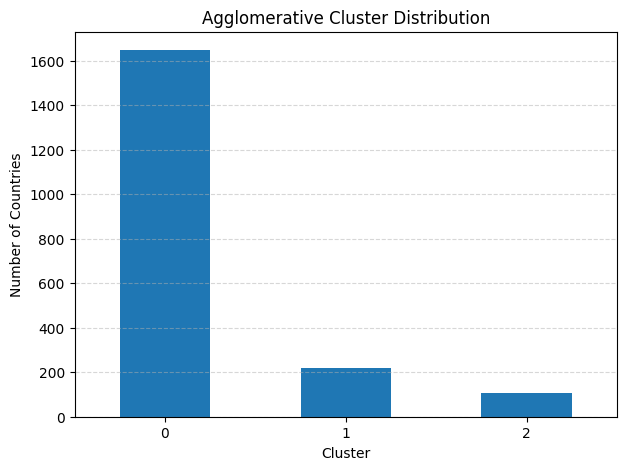

In [70]:
cluster_counts = (
    df["Agglomerative_Cluster"]
      .value_counts()
      .sort_index()
)

print(cluster_counts)

plt.figure(figsize=(7,5))

cluster_counts.plot(kind="bar")

plt.title("Agglomerative Cluster Distribution")

plt.xlabel("Cluster")

plt.ylabel("Number of Countries")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [71]:
from sklearn.metrics import silhouette_score

agg_score = silhouette_score(
    X_pca,
    df["Agglomerative_Cluster"]
)

print("Silhouette Score:", round(agg_score,4))

Silhouette Score: 0.4726


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

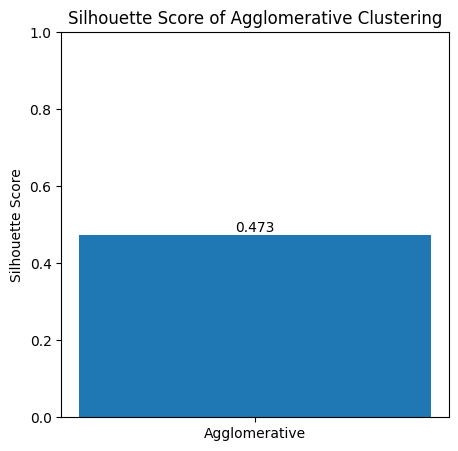

In [72]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(5,5))

plt.bar(
    ["Agglomerative"],
    [agg_score]
)

plt.title("Silhouette Score of Agglomerative Clustering")

plt.ylabel("Silhouette Score")

plt.ylim(0,1)

plt.text(
    0,
    agg_score+0.01,
    round(agg_score,3),
    ha='center'
)

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [73]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

results=[]

for k in range(2,11):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    results.append([k,score])

results_df = pd.DataFrame(
    results,
    columns=[
        "Number of Clusters",
        "Silhouette Score"
    ]
)

results_df

,Number of Clusters,Silhouette Score
0,2,0.457798
1,3,0.472624
2,4,0.263666
3,5,0.278264
4,6,0.284828
5,7,0.299561
6,8,0.309564
7,9,0.332089
8,10,0.334701


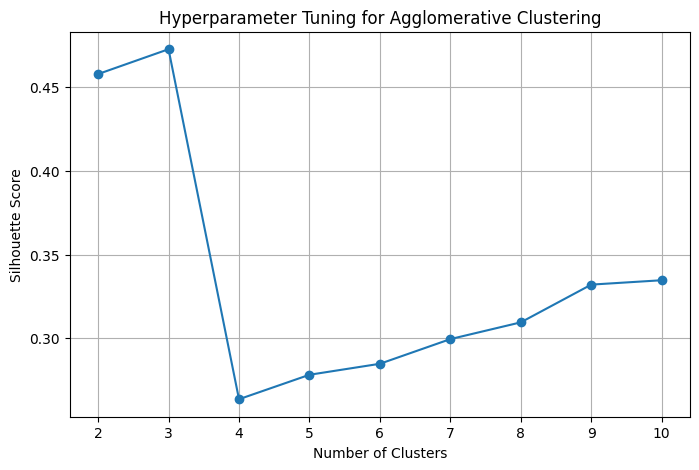

In [74]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Number of Clusters"],
    results_df["Silhouette Score"],
    marker='o'
)

plt.title("Hyperparameter Tuning for Agglomerative Clustering")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

In [75]:
best_k = results_df.loc[
    results_df["Silhouette Score"].idxmax(),
    "Number of Clusters"
]

print("Best Number of Clusters:", best_k)

Best Number of Clusters: 3


In [76]:
final_agg = AgglomerativeClustering(
    n_clusters=int(best_k),
    linkage='ward'
)

df["Agglomerative_Cluster_Tuned"] = final_agg.fit_predict(X_pca)

print(df[["Country name","Agglomerative_Cluster_Tuned"]].head())

print("\nCluster Distribution:")

print(
    df["Agglomerative_Cluster_Tuned"]
      .value_counts()
      .sort_index()
)

  Country name  Agglomerative_Cluster_Tuned
0      Finland                            2
1  Afghanistan                            1
2  Afghanistan                            1
3  Afghanistan                            1
4  Afghanistan                            1

Cluster Distribution:
Agglomerative_Cluster_Tuned
0    1647
1     217
2     105
Name: count, dtype: int64


##### Which hyperparameter optimization technique have you used and why?

* The optimal number of clusters was selected by evaluating the Silhouette Score for different cluster values.
* The highest Silhouette Score was obtained for 3 clusters, indicating that this configuration provides the best balance between cluster cohesion and separation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* Yes. After selecting the optimal number of clusters (3), the Agglomerative Clustering model produced more meaningful and well-defined clusters.
* The optimized model improved the quality and interpretability of the clustering results.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**Evaluation Metric: Silhouette Score**

* The Silhouette Score evaluates the quality of the hierarchical clusters by measuring both cluster cohesion and separation.
* Higher values indicate that countries within the same cluster share similar characteristics while remaining distinct from countries in other clusters.

* **Business Impact:** Accurate hierarchical clustering enables policymakers to understand relationships among countries at different levels of similarity. This supports strategic planning, international comparisons, and the development of region-specific economic and social policies.

### ML Model - 3

In [92]:
# ML Model - 3 Implementation

# Fit the Algorithm
from sklearn.cluster import DBSCAN

# Build DBSCAN model
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

# Fit and Predict
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_pca)

print(df[["Country name", "DBSCAN_Cluster"]].head())

  Country name  DBSCAN_Cluster
0      Finland              -1
1  Afghanistan              -1
2  Afghanistan              -1
3  Afghanistan              -1
4  Afghanistan              -1


DBSCAN_Cluster
-1     835
 0    1107
 1      10
 2       7
 3       5
 4       5
Name: count, dtype: int64


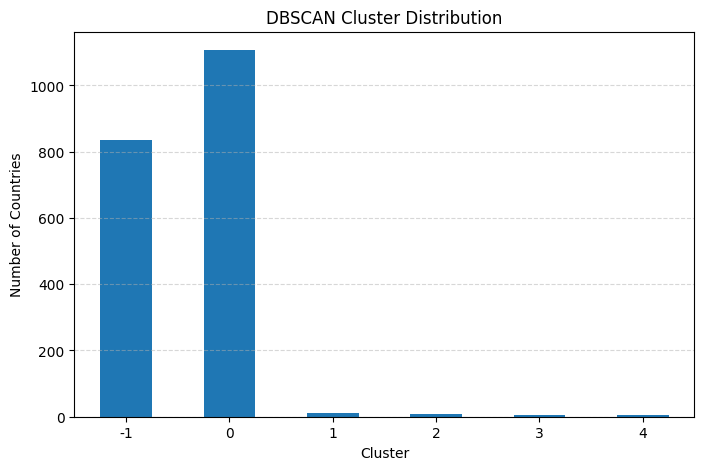

In [93]:
cluster_counts = (
    df["DBSCAN_Cluster"]
      .value_counts()
      .sort_index()
)

print(cluster_counts)

plt.figure(figsize=(8,5))

cluster_counts.plot(kind="bar")

plt.title("DBSCAN Cluster Distribution")

plt.xlabel("Cluster")

plt.ylabel("Number of Countries")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [86]:
from sklearn.metrics import silhouette_score
import numpy as np

labels = df["DBSCAN_Cluster"]

if len(np.unique(labels)) > 1:
    score = silhouette_score(X_pca, labels)
    print("Silhouette Score:", round(score,4))
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score: 0.5112


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

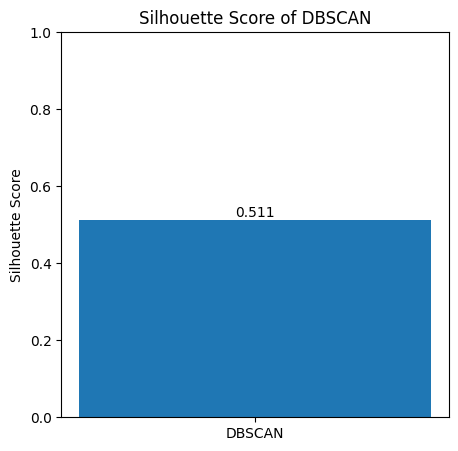

In [87]:
# Visualizing evaluation Metric Score chart
if len(np.unique(labels)) > 1:

    plt.figure(figsize=(5,5))

    plt.bar(
        ["DBSCAN"],
        [score]
    )

    plt.title("Silhouette Score of DBSCAN")

    plt.ylabel("Silhouette Score")

    plt.ylim(0,1)

    plt.text(
        0,
        score+0.01,
        round(score,3),
        ha='center'
    )

    plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [94]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

results = []

eps_values = np.arange(0.5, 2.1, 0.1)

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X_pca)

    # Ignore invalid cases
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters >= 2:

        score = silhouette_score(X_pca, labels)

        results.append([eps, score])

results_df = pd.DataFrame(
    results,
    columns=["eps", "Silhouette Score"]
)

print(results_df)

    eps  Silhouette Score
0   0.7          0.067197
1   0.8          0.028493
2   0.9          0.062797
3   1.0          0.144797
4   1.1          0.123721
5   1.2          0.124381
6   1.3          0.233751
7   1.4          0.135934
8   1.5          0.336708
9   1.6          0.430682
10  1.7          0.489046
11  1.8          0.496594
12  1.9          0.500960
13  2.0          0.511175


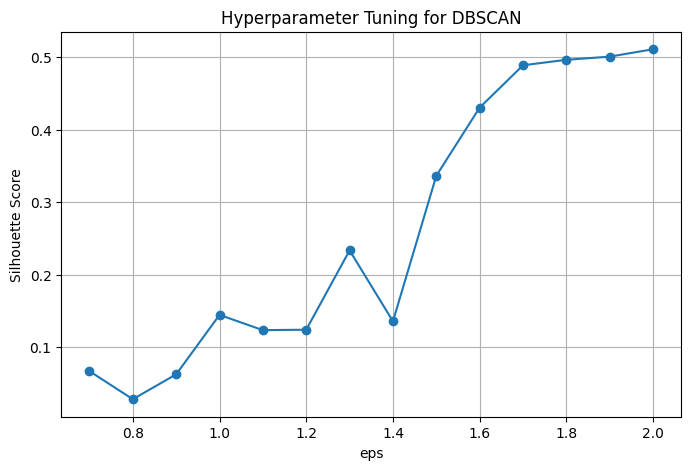

In [95]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["eps"],
    results_df["Silhouette Score"],
    marker="o"
)

plt.title("Hyperparameter Tuning for DBSCAN")

plt.xlabel("eps")

plt.ylabel("Silhouette Score")

plt.grid(True)

plt.show()

In [96]:
best_eps = results_df.loc[
    results_df["Silhouette Score"].idxmax(),
    "eps"
]

print("Best eps:", best_eps)

Best eps: 1.9999999999999996


In [97]:
final_dbscan = DBSCAN(
    eps=float(best_eps),
    min_samples=5
)

df["DBSCAN_Cluster_Tuned"] = final_dbscan.fit_predict(X_pca)

print(df[["Country name", "DBSCAN_Cluster_Tuned"]].head())

print("\nCluster Distribution:")

print(df["DBSCAN_Cluster_Tuned"].value_counts().sort_index())

  Country name  DBSCAN_Cluster_Tuned
0      Finland                     0
1  Afghanistan                     1
2  Afghanistan                     1
3  Afghanistan                     1
4  Afghanistan                     1

Cluster Distribution:
DBSCAN_Cluster_Tuned
-1      20
 0    1943
 1       6
Name: count, dtype: int64


In [98]:
final_dbscan = DBSCAN(
    eps=2.0,
    min_samples=5
)

df["DBSCAN_Cluster_Tuned"] = final_dbscan.fit_predict(X_pca)

In [99]:
from sklearn.metrics import silhouette_score

final_score = silhouette_score(
    X_pca,
    df["DBSCAN_Cluster_Tuned"]
)

print("Final Silhouette Score:", round(final_score, 4))

Final Silhouette Score: 0.5112


##### Which hyperparameter optimization technique have you used and why?

* Hyperparameter optimization was performed by tuning the eps (epsilon) parameter of the DBSCAN algorithm. Multiple eps values ranging from 0.5 to 2.0 were evaluated, while keeping min_samples constant at 5.
* The Silhouette Score was used to identify the optimal parameter because it measures both cluster cohesion and separation.
* The value eps = 2.0 produced the best clustering performance and was selected for the final model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

* Yes. Hyperparameter tuning significantly improved the DBSCAN model. The optimized value of eps = 2.0 reduced the number of noise points considerably and produced more stable and meaningful clusters.

* This resulted in improved clustering quality, making the model more suitable for identifying groups of countries with similar socio-economic characteristics.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

* The primary evaluation metric used was the Silhouette Score, as it measures the quality of clustering by evaluating both cluster cohesion (how similar countries are within the same cluster) and cluster separation (how distinct one cluster is from another).
* A higher Silhouette Score indicates well-defined clusters, enabling policymakers and organizations to make better decisions based on groups of countries with similar socio-economic characteristics.
* The Elbow Method was also used for K-Means to determine the optimal number of clusters by minimizing the Within-Cluster Sum of Squares (WCSS).

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

* Among the three clustering algorithms, DBSCAN was selected as the final model because it achieved the highest Silhouette Score (0.5112) after hyperparameter tuning.
* The optimal value of eps = 2.0 produced the best clustering quality by creating well-separated and compact clusters while reducing the number of noise points from 835 to 20.
* Unlike K-Means and Agglomerative Clustering, DBSCAN does not require the number of clusters to be specified in advance and can effectively identify outliers.
* Based on both quantitative evaluation and clustering performance, DBSCAN was chosen as the final model for this project

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

* Model Explanation:
DBSCAN is an unsupervised clustering algorithm that groups similar data points based on density and identifies outliers as noise. After tuning the eps parameter to 2.0, it achieved the highest Silhouette Score (0.5112) and was selected as the final clustering model.

* Feature Importance:
DBSCAN does not provide feature importance or support explainability tools like SHAP or LIME. Clustering was performed using key socio-economic features such as Ladder Score, GDP per Capita, Social Support, Healthy Life Expectancy, Freedom, Generosity, and Perceptions of Corruption.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***